In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

estoque = pd.read_csv('../dados/estoque.csv', sep=';')
vendas = pd.read_csv('../dados/vendas.csv', sep=';')

print(estoque.shape, vendas.shape)
estoque.head()

(51, 6) (72, 8)


,marca_carro,modelo_carro,cor_carro,ano_fabricacao,ano_modelo,local_carro
0,FIAT,ARGO 1.0,BRANCO,2022,2023,ESTOQUE
1,FIAT,ARGO DRIVE 1.0,CINZA,2019,2020,ESTOQUE
2,FIAT,ARGO DRIVE 1.0,PRATA,2020,2020,ESTOQUE
3,CITROEN,C3 LIVE PK 1.0,BRANCO,2023,2024,ESTOQUE
4,HONDA,CB600F HORNET,VERMELHA,2014,2014,ESTOQUE


In [10]:

vendas['data_venda'] = pd.to_datetime(vendas['data_venda'])


In [11]:
print("Colunas do Estoque:", estoque.columns.tolist())
print("Colunas de Vendas:", vendas.columns.tolist())

Colunas do Estoque: ['marca_carro', 'modelo_carro', 'cor_carro', 'ano_fabricacao', 'ano_modelo', 'local_carro']
Colunas de Vendas: ['data_venda', 'marca_carro', 'modelo_carro', 'ano_fabricacao', 'ano_modelo', 'dias_estoque', 'valor_venda ', 'vendedor_carro']


In [13]:
# 1. Converter apenas a data que existe no seu arquivo (vendas)
vendas['data_venda'] = pd.to_datetime(vendas['data_venda'])

# 2. Verificar valores nulos no estoque usando a estrutura real
print("Nulos no estoque:")
print(estoque.isnull().sum())

# 3. Tratar os textos de marca e modelo usando os nomes reais das colunas (com _carro)
estoque['marca_carro'] = estoque['marca_carro'].str.upper().str.strip()
estoque['modelo_carro'] = estoque['modelo_carro'].str.upper().str.strip()

Nulos no estoque:
marca_carro       0
modelo_carro      0
cor_carro         0
ano_fabricacao    0
ano_modelo        0
local_carro       0
dtype: int64


In [16]:
# 1. Remover espaços invisíveis do nome de todas as colunas das duas tabelas
estoque.columns = estoque.columns.str.strip()
vendas.columns = vendas.columns.str.strip()

# 2. Agora o 'valor_venda' vai funcionar perfeitamente sem o espaço no final!
vendas['valor_venda'] = vendas['valor_venda'].astype(str).str.replace('.', '', regex=False)
vendas['valor_venda'] = pd.to_numeric(vendas['valor_venda'], errors='coerce')

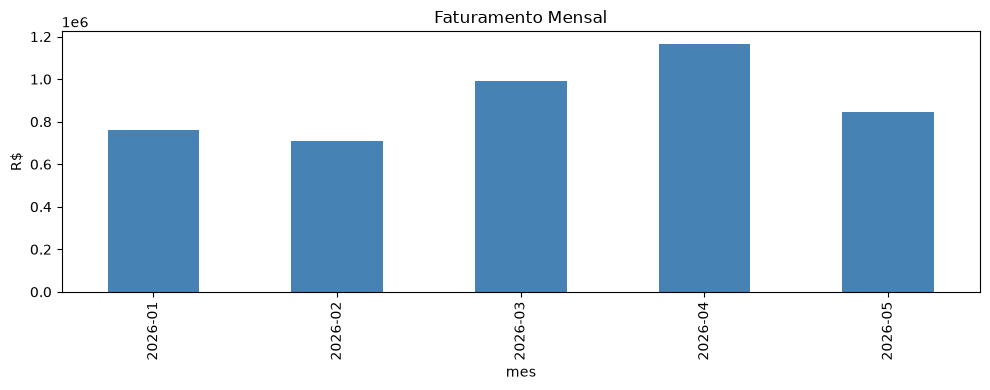

In [17]:
# 1. Criar a coluna de período (Ano-Mês) para o agrupamento
vendas['mes'] = vendas['data_venda'].dt.to_period('M')

# 2. Agrupar por mês e somar os valores de venda (agora que a coluna está limpa de espaços e pontos)
fat_mensal = vendas.groupby('mes')['valor_venda'].sum()

# 3. Configurar e renderizar o gráfico com o Matplotlib
plt.figure(figsize=(10,4))
fat_mensal.plot(kind='bar', color='steelblue')
plt.title('Faturamento Mensal')
plt.ylabel('R$')
plt.tight_layout()

# 4. Salvar a imagem gerada no seu computador
plt.savefig('faturamento_mensal.png', dpi=150)
plt.show()

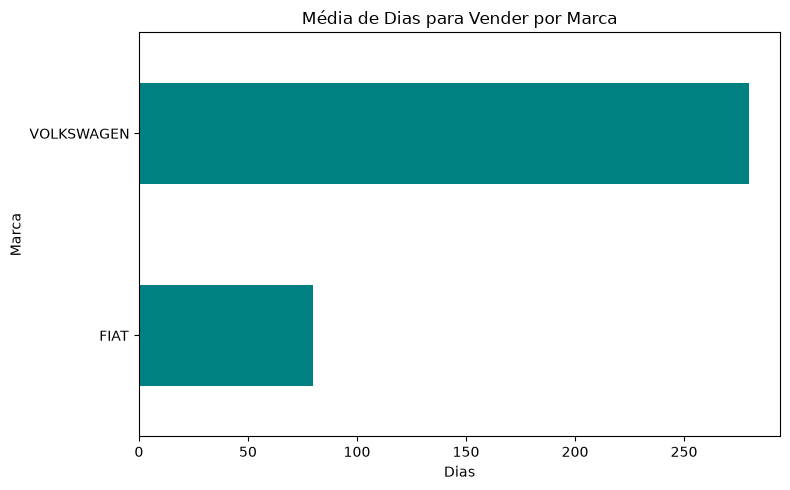

In [18]:
# 1. Realizar a junção (merge) das tabelas usando as colunas correspondentes que existem em ambas
df = vendas.merge(estoque, on=['marca_carro', 'modelo_carro', 'ano_fabricacao', 'ano_modelo'])

# 2. Agrupar pela marca real ('marca_carro') e calcular a média da coluna real de dias ('dias_estoque')
giro = df.groupby('marca_carro')['dias_estoque'].mean().sort_values()

# 3. Configurar e desenhar o gráfico de barras horizontais
plt.figure(figsize=(8,5))
giro.plot(kind='barh', color='teal')
plt.title('Média de Dias para Vender por Marca')
plt.xlabel('Dias')
plt.ylabel('Marca')
plt.tight_layout()

# 4. Salvar o gráfico do giro de estoque
plt.savefig('giro_por_marca.png', dpi=150)
plt.show()


## Principais Insights

- O mês com maior faturamento foi **abril de 2026 (2026-04)** com **R$ 1.166.600,00**
- A marca com menor giro de estoque foi **FIAT** (média de **79.7 dias**)
- Os 3 modelos mais vendidos foram: **ARGO DRIVE 1.0**, **RENEGADE LNGTD AT** e **STRADA FREEDOM 13CS**

Análise feita com dados reais da loja Revenda Mais.

In [22]:
# Executar para descobrir os valores exatos dos Insights:

# 1. Mês com maior faturamento
mes_maior = fat_mensal.idxmax()
valor_maior = fat_mensal.max()
print(f"1. Maior faturamento: Mês {mes_maior} com R$ {valor_maior:,.2f}")

# 2. Marca com menor tempo de giro (vende mais rápido)
marca_rapida = giro.idxmin()
tempo_medio = giro.min()
print(f"2. Menor tempo de pátio: {marca_rapida} com média de {tempo_medio:.1f} dias")

# 3. Modelos mais vendidos
top_modelos = vendas['modelo_carro'].value_counts().head(3)
print("\n3. Três modelos mais vendidos:")
for i, (modelo, qtd) in enumerate(top_modelos.items(), 1):
    print(f"   Modelo {i}: {modelo} ({qtd} vendas)")

1. Maior faturamento: Mês 2026-04 com R$ 1,166,600.00
2. Menor tempo de pátio: FIAT com média de 79.7 dias

3. Três modelos mais vendidos:
   Modelo 1: ARGO DRIVE 1.0 (4 vendas)
   Modelo 2: RENEGADE LNGTD AT (4 vendas)
   Modelo 3: STRADA FREEDOM 13CS (3 vendas)
